# Association rules with Apriori

### Finding what goes with what, and then throwing most of it away

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How Apriori uses downward closure to avoid an impossible search, how to write it in NumPy and check it against mlxtend, what support and confidence thresholds actually trade against each other, why a high-confidence rule is often worthless, and how many rules survive each filter |
| **You should already know** | Nothing beyond basic probability. This chapter needs no model and no train-test split |
| **Dataset** | UCI Bike Sharing (17,379 hours), binned into transactions. The encoding is defended and its sensitivity measured |
| **Runtime** | One to two minutes on a laptop CPU |
| **Next** | [06-01 Principal Component Analysis](../../06-dimensionality-reduction/01-principal-component-analysis/) |

---

## 1. The idea

Everything else in [part 5](../) groups rows. Association rule mining groups
**columns within a row**. The classic setting is a supermarket: each transaction
is a basket, each basket is a set of items, and you want statements of the form

> people who bought bread and butter also bought jam

written `{bread, butter} => {jam}`. The left side is the **antecedent**, the
right side the **consequent**, and together they are a **rule**.

The trouble is arithmetic. With $d$ distinct items there are $2^d$ possible
itemsets, so a supermarket with a hundred products has more candidate itemsets
than there are atoms in anything you would care to name. Apriori exists because
of one observation, and this notebook is largely about that observation and about
what you do with the flood of rules it produces.

The second half is more useful than the first. Apriori will hand you thousands of
rules, most of which are true, boring, and already known to whoever asked. The
skill is the filtering, and the filtering has a trap in it that section 5 walks
into deliberately.

### Where the baskets come from

This book's house datasets do not include a retail transaction file, so the
baskets here are built from Bike Sharing by binning each hour into a set of
conditions. One hour becomes one transaction. That encoding is a real choice and
it deserves a defence rather than a shrug, so here is the defence and the two
places it differs from a shopping basket.

Every hour is described by nine variables, and each variable contributes exactly
one item. So **every transaction has the same length**, which a supermarket
basket never does. And **items from the same variable are mutually exclusive**:
no itemset can contain two temperature bands. That removes a large class of
itemsets before we start, and it pushes typical support values far above what
retail data gives, where any single product is in a tiny fraction of baskets.

The bin edges are named rather than automatic, so a reader can check them:
temperature bands, humidity bands and wind bands are cut at values you can state
out loud, not at whatever the quartiles happened to be. Section 4 re-runs the
whole thing with equal-frequency bins instead and prints how much the answer
moved, because that is the honest way to defend a binning choice.

In [1]:
import sys
import pathlib
import math
import time
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X_bike, y_bike = datasets.bike_sharing()
hours = X_bike.copy()
hours["cnt"] = y_bike.values
print(f"{len(hours):,} hours, columns: {', '.join(hours.columns)}")

17,379 hours, columns: season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt


In [2]:
SEASONS = {1: "season=spring", 2: "season=summer", 3: "season=autumn", 4: "season=winter"}
WEATHER = {1: "weather=clear", 2: "weather=mist", 3: "weather=light_rain",
           4: "weather=heavy_rain"}
HOUR_EDGES = [0, 6, 12, 18, 24]
HOUR_LABELS = ["time=night", "time=morning", "time=afternoon", "time=evening"]


def build_items(frame, continuous="named"):
    """One row per hour, one column per variable, each cell a single item string.

    `continuous="named"` cuts temperature, humidity and wind at stated physical
    values. `continuous="quantile"` cuts them into equal-sized groups instead,
    which is the alternative measured later in section 4.
    """
    items = pd.DataFrame(index=frame.index)
    items["season"] = frame["season"].map(SEASONS)
    # right=False so the bands are [0,6), [6,12), [12,18), [18,24) and hour 6 is
    # morning rather than the last hour of night.
    items["time"] = pd.cut(frame["hr"], HOUR_EDGES, right=False,
                           labels=HOUR_LABELS).astype(str)
    items["day"] = np.where(frame["workingday"] == 1, "day=working", "day=off")
    items["holiday"] = np.where(frame["holiday"] == 1, "holiday=yes", "holiday=no")
    items["weather"] = frame["weathersit"].map(WEATHER)

    if continuous == "named":
        # temp is normalised by 41 C, so 0.3 is about 12 C and 0.7 about 29 C.
        items["temp"] = pd.cut(frame["temp"], [-0.01, 0.3, 0.5, 0.7, 1.01],
                               labels=["temp=cold", "temp=mild", "temp=warm",
                                       "temp=hot"]).astype(str)
        items["humidity"] = pd.cut(frame["hum"], [-0.01, 0.4, 0.7, 1.01],
                                   labels=["humidity=dry", "humidity=moderate",
                                           "humidity=humid"]).astype(str)
        items["wind"] = pd.cut(frame["windspeed"], [-0.01, 0.15, 0.30, 1.01],
                               labels=["wind=calm", "wind=breezy", "wind=windy"]).astype(str)
    else:
        # rank first: windspeed has thousands of tied zeros and qcut cannot split
        # a tie, so without the rank the bin edges collapse into each other.
        for column, prefix, names in [("temp", "temp", ["cold", "mild", "warm", "hot"]),
                                      ("hum", "humidity", ["dry", "moderate", "humid"]),
                                      ("windspeed", "wind", ["calm", "breezy", "windy"])]:
            items[prefix] = pd.qcut(frame[column].rank(method="first"), len(names),
                                    labels=[f"{prefix}={n}" for n in names]).astype(str)

    items["demand"] = pd.qcut(frame["cnt"], 3,
                              labels=["demand=low", "demand=medium",
                                      "demand=high"]).astype(str)
    return items


def to_basket(items):
    """One-hot the item strings. mlxtend wants booleans, and so does the scratch code."""
    return pd.get_dummies(items, prefix="", prefix_sep="")


MIN_SUPPORT = 0.03
MAX_LEN = 3
MIN_CONFIDENCE = 0.50
LIFT_FLOOR = 1.10
COMMON_CONSEQUENT = 0.50

items = build_items(hours)
basket = to_basket(items)
item_names = list(basket.columns)
onehot = basket.to_numpy()
item_support = pd.Series(onehot.mean(axis=0), index=item_names).sort_values(ascending=False)

print(f"{len(basket):,} transactions, {len(item_names)} distinct items, "
      f"{items.shape[1]} variables")
print(f"items per transaction: min {onehot.sum(axis=1).min()}, "
      f"max {onehot.sum(axis=1).max()}")
print("\nsupport of every item, most common first:")
print(item_support.round(4).to_string())
print(f"\nitems in more than {COMMON_CONSEQUENT:.0%} of hours: "
      f"{int((item_support > COMMON_CONSEQUENT).sum())}")

17,379 transactions, 29 distinct items, 9 variables
items per transaction: min 9, max 9

support of every item, most common first:
holiday=no            0.9712
day=working           0.6827
weather=clear         0.6567
humidity=moderate     0.4857
wind=breezy           0.4612
wind=calm             0.4005
humidity=humid        0.3717
temp=warm             0.3357
demand=medium         0.3351
demand=low            0.3336
demand=high           0.3314
day=off               0.3173
temp=mild             0.3076
weather=mist          0.2615
season=autumn         0.2587
season=summer         0.2537
time=afternoon        0.2517
time=evening          0.2513
time=morning          0.2509
time=night            0.2460
season=spring         0.2441
season=winter         0.2435
temp=cold             0.2022
temp=hot              0.1545
humidity=dry          0.1426
wind=windy            0.1383
weather=light_rain    0.0817
holiday=yes           0.0288
weather=heavy_rain    0.0002

items in more than 50% of h


the most common items are the ones that will cause trouble later:
holiday=no       0.9712
day=working      0.6827
weather=clear    0.6567


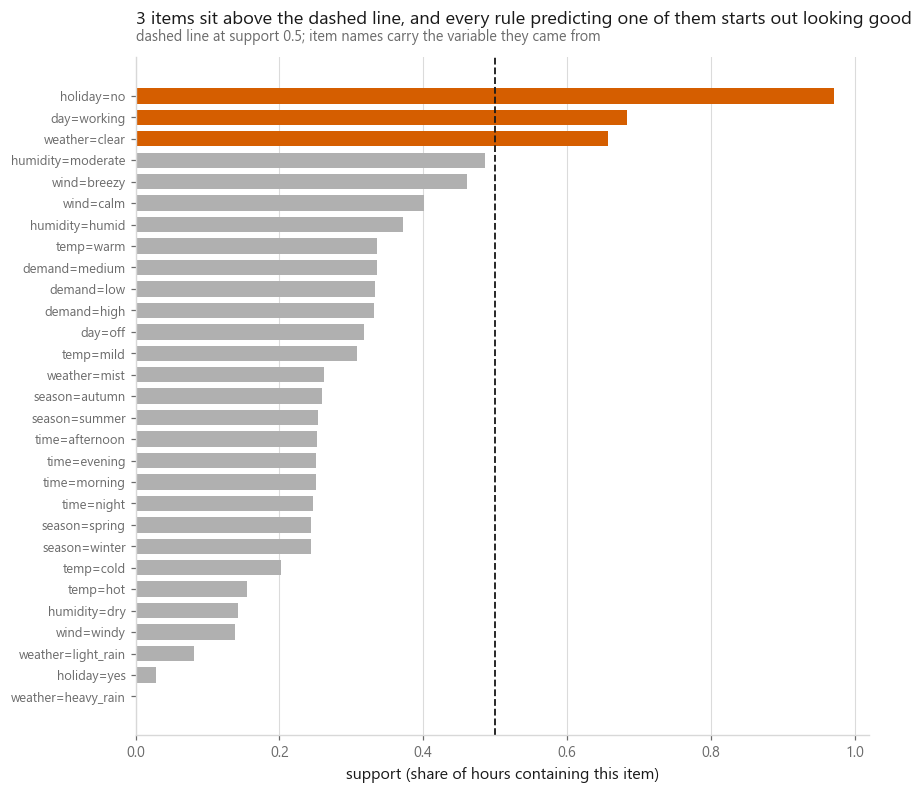

In [3]:
order = item_support.index[::-1]
ordered = item_support.loc[order]
too_common = ordered > COMMON_CONSEQUENT

fig, ax = plt.subplots(figsize=(8.6, 8.0))
ax.barh(range(len(order)), ordered.to_numpy(), height=0.72,
        color=[style.HIGHLIGHT if flag else style.NEUTRAL for flag in too_common])
ax.axvline(COMMON_CONSEQUENT, color=style.INK, ls="--", lw=1.2)
ax.set_yticks(range(len(order)), order, fontsize=8.5)
ax.set_xlabel("support (share of hours containing this item)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax,
            f"{int(too_common.sum())} items sit above the dashed line, and every rule "
            f"predicting one of them starts out looking good",
            f"dashed line at support {COMMON_CONSEQUENT}; item names carry the variable "
            f"they came from")
style.save(fig, FIG / "fig-01-item-support.png")

print("\nthe most common items are the ones that will cause trouble later:")
print(item_support.head(3).round(4).to_string())

Look at the top of that list before going any further, because it is the setup
for the trap later on. One item covers almost every hour. A rule that predicts it
will be right almost every time and will have told you nothing.

## 2. The maths

Three numbers, and the third is the one people skip.

**Support** of an itemset is the fraction of transactions containing all of it:

$$\mathrm{supp}(X) = \frac{|\{t : X \subseteq t\}|}{|T|}$$

**Confidence** of a rule is the conditional probability of the consequent given
the antecedent:

$$\mathrm{conf}(X \Rightarrow Y) = \frac{\mathrm{supp}(X \cup Y)}{\mathrm{supp}(X)}$$

**Lift** divides that by how often the consequent happens anyway:

$$\mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{conf}(X \Rightarrow Y)}{\mathrm{supp}(Y)}
= \frac{\mathrm{supp}(X \cup Y)}{\mathrm{supp}(X)\,\mathrm{supp}(Y)}$$

Lift is 1 exactly when $X$ and $Y$ are independent. Above 1 they co-occur more
than chance, below 1 less. Note that lift is symmetric in $X$ and $Y$ while
confidence is not, which is a hint that neither number is a statement about
causation and only one of them is even a statement about direction.

### Downward closure, which is why any of this is possible

The one observation Apriori is built on:

> If an itemset is frequent, every subset of it is frequent.

It is nearly a tautology. Every transaction containing $\{a, b, c\}$ also
contains $\{a, b\}$, so $\mathrm{supp}(\{a,b\}) \ge \mathrm{supp}(\{a,b,c\})$.
Read it backwards and it becomes an algorithm:

> If any subset of a candidate is infrequent, the candidate is infrequent.

So you never have to count it. Apriori works upward one size at a time, and at
each size it only builds candidates whose subsets are all already known to be
frequent. Section 3 counts how much that saves.

## 3. From scratch

In [4]:
def support_of(onehot, items_tuple):
    """Fraction of rows where every column in `items_tuple` is True."""
    return float(onehot[:, list(items_tuple)].all(axis=1).mean())


def generate_candidates(previous, k, prune=True):
    """The F(k-1) x F(k-1) join.

    Two frequent (k-1)-itemsets that agree on their first k-2 items merge into one
    candidate of size k. Because `previous` is sorted, once two entries stop
    sharing that prefix no later entry will share it either, so the inner loop
    breaks instead of running to the end.

    With `prune=True` the candidate then has to pass the downward-closure test:
    every one of its (k-1)-subsets must itself be frequent.
    """
    previous = sorted(previous)
    known = set(previous)
    out = []
    for i in range(len(previous)):
        for j in range(i + 1, len(previous)):
            a, b = previous[i], previous[j]
            if a[:k - 2] != b[:k - 2]:
                break
            candidate = a + (b[k - 2],)
            if prune and not all(sub in known for sub in combinations(candidate, k - 1)):
                continue
            out.append(candidate)
    return out


def apriori_scratch(onehot, min_support, max_len=3, prune=True):
    """Apriori. Returns the frequent itemsets and a per-level accounting."""
    n_items = onehot.shape[1]
    frequent = {}
    ledger = []

    level = [(i,) for i in range(n_items)]
    k = 1
    while level and k <= max_len:
        kept = []
        for candidate in level:
            support = support_of(onehot, candidate)
            if support >= min_support:
                frequent[candidate] = support
                kept.append(candidate)
        ledger.append({"size": k, "all subsets of all items": math.comb(n_items, k),
                       "candidates counted": len(level), "found frequent": len(kept)})
        k += 1
        level = generate_candidates(kept, k, prune=prune)
    return frequent, pd.DataFrame(ledger)


start = time.perf_counter()
frequent, ledger_pruned = apriori_scratch(onehot, MIN_SUPPORT, MAX_LEN, prune=True)
scratch_seconds = time.perf_counter() - start

_, ledger_unpruned = apriori_scratch(onehot, MIN_SUPPORT, MAX_LEN, prune=False)

ledger = ledger_pruned.copy()
ledger["candidates without the subset check"] = ledger_unpruned["candidates counted"]
ledger = ledger[["size", "all subsets of all items",
                 "candidates without the subset check", "candidates counted",
                 "found frequent"]]

print(f"min_support = {MIN_SUPPORT}, itemsets up to size {MAX_LEN}, "
      f"{scratch_seconds:.2f} s\n")
print(ledger.to_string(index=False))
print(f"\ntotal frequent itemsets found: {len(frequent):,}")
print(f"support counts performed with the subset check    : "
      f"{ledger['candidates counted'].sum():,}")
print(f"support counts performed without the subset check : "
      f"{ledger['candidates without the subset check'].sum():,}")
print(f"support counts a method with no pruning at all would need : "
      f"{ledger['all subsets of all items'].sum():,}")

min_support = 0.03, itemsets up to size 3, 0.06 s

 size  all subsets of all items  candidates without the subset check  candidates counted  found frequent
    1                        29                                   29                  29              27
    2                       406                                  351                 351             275
    3                      3654                                 1870                1505            1000

total frequent itemsets found: 1,302
support counts performed with the subset check    : 1,885
support counts performed without the subset check : 2,250
support counts a method with no pruning at all would need : 4,089


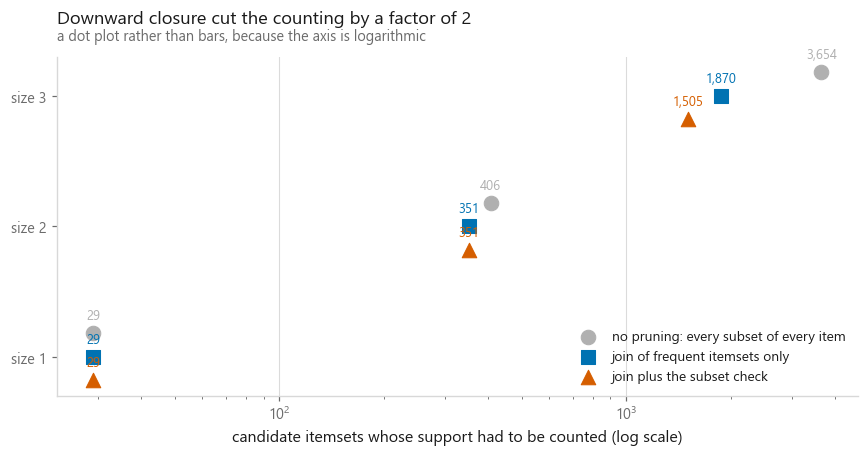

In [5]:
fig, ax = plt.subplots(figsize=(9.4, 4.0))
levels = ledger["size"].to_numpy()
series = [("no pruning: every subset of every item", "all subsets of all items",
           style.NEUTRAL, style.MARKERS[0]),
          ("join of frequent itemsets only", "candidates without the subset check",
           style.PALETTE[0], style.MARKERS[1]),
          ("join plus the subset check", "candidates counted",
           style.HIGHLIGHT, style.MARKERS[2])]

for offset, (label, column, colour, marker) in zip([0.18, 0.0, -0.18], series):
    ax.scatter(ledger[column], levels + offset, s=90, marker=marker, color=colour,
               label=label, zorder=3)
    for x, lvl in zip(ledger[column], levels):
        ax.annotate(f"{x:,}", xy=(x, lvl + offset), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=8.5,
                    color=colour)
ax.set_xscale("log")
ax.set_yticks(levels, [f"size {lvl}" for lvl in levels])
ax.set_xlabel("candidate itemsets whose support had to be counted (log scale)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right", fontsize=9)
saved = ledger["all subsets of all items"].sum() / ledger["candidates counted"].sum()
style.title(ax, f"Downward closure cut the counting by a factor of {saved:.0f}",
            f"a dot plot rather than bars, because the axis is logarithmic")
style.save(fig, FIG / "fig-02-pruning.png")

Read the numbers on that plot rather than the positions, since the axis is
logarithmic and logarithmic distances flatter small savings.

At size 1 there is nothing to prune yet, so all three markers land on the same
value. From size 2 onward the gap between the first and second marker is
downward closure doing the heavy work: candidates are only ever built out of
itemsets already known to be frequent, so an item that failed the support floor
takes every itemset containing it out of the search with it.

The gap between the second and third marker is the subset check. It is cheaper
than it looks and it catches candidates the join is too crude to reject. Many of
the ones it catches here are impossible by construction, because they hold two
items from the same variable and no hour can have two temperatures.

### Checking it against mlxtend

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

start = time.perf_counter()
frequent_df = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
mlxtend_seconds = time.perf_counter() - start

mine = {frozenset(item_names[i] for i in key): value for key, value in frequent.items()}
theirs = {frozenset(s): v for s, v in zip(frequent_df["itemsets"], frequent_df["support"])}

print(f"ours    : {len(mine):,} frequent itemsets, {scratch_seconds:.2f} s")
print(f"mlxtend : {len(theirs):,} frequent itemsets, {mlxtend_seconds:.2f} s")
print(f"same set of itemsets: {set(mine) == set(theirs)}")
if set(mine) == set(theirs):
    worst = max(abs(mine[k] - theirs[k]) for k in mine)
    print(f"largest disagreement in support: {worst:.2e}")

ours    : 1,302 frequent itemsets, 0.06 s
mlxtend : 1,302 frequent itemsets, 0.07 s
same set of itemsets: True
largest disagreement in support: 0.00e+00


## 4. In practice: turning itemsets into rules

One itemset makes several rules, one for each way of choosing which of its items
go on the left of the arrow, so the rule count comes out larger than the itemset
count before any filtering happens. mlxtend does the splitting and the metric
arithmetic.

`num_itemsets` below is only used by mlxtend's missing-data machinery, which is
switched off here because there is no missing data. It cancels out of confidence
and lift either way.

In [7]:
all_rules = association_rules(frequent_df, num_itemsets=len(basket),
                              metric="confidence", min_threshold=0.0)


def readable(rules, n=8, by="lift"):
    """The top rules by one metric, printed as sentences instead of frozensets."""
    out = rules.sort_values(by, ascending=False).head(n).copy()
    out["rule"] = [f"{' + '.join(sorted(a))}  =>  {' + '.join(sorted(c))}"
                   for a, c in zip(out["antecedents"], out["consequents"])]
    return out[["rule", "support", "confidence", "consequent support", "lift"]].to_string(
        index=False, float_format=lambda v: f"{v:.3f}")


print(f"rules generated from {len(frequent_df):,} frequent itemsets: {len(all_rules):,}\n")
print("the highest-confidence rules")
print(readable(all_rules, 8, by="confidence"))

rules generated from 1,302 frequent itemsets: 6,550

the highest-confidence rules
                                        rule  support  confidence  consequent support  lift
                 day=working  =>  holiday=no    0.683       1.000               0.971 1.030
    day=working + time=night  =>  holiday=no    0.168       1.000               0.971 1.030
  day=working + time=evening  =>  holiday=no    0.172       1.000               0.971 1.030
day=working + time=afternoon  =>  holiday=no    0.172       1.000               0.971 1.030
 day=working + season=summer  =>  holiday=no    0.176       1.000               0.971 1.030
    humidity=dry + temp=warm  =>  holiday=no    0.033       1.000               0.971 1.030
     day=working + wind=calm  =>  holiday=no    0.276       1.000               0.971 1.030
   day=working + wind=breezy  =>  holiday=no    0.312       1.000               0.971 1.030


Read the `consequent support` column next to the `confidence` column in that
table. That pairing is the whole of section 5, arriving early.

### What the thresholds actually cost you

Support and confidence are the two dials everyone turns first, usually by
guessing. Here is the surface they define.

In [8]:
support_grid = [0.02, 0.04, 0.06, 0.10, 0.15]
confidence_grid = [0.30, 0.50, 0.70, 0.90]
LIFT_COLUMN = f"rules with lift >= {LIFT_FLOOR}"

counts = []
for s in support_grid:
    freq_s = apriori(basket, min_support=s, use_colnames=True, max_len=MAX_LEN)
    rules_s = association_rules(freq_s, num_itemsets=len(basket),
                                metric="confidence", min_threshold=0.0)
    for c in confidence_grid:
        selected = rules_s[rules_s["confidence"] >= c]
        counts.append({"min_support": s, "min_confidence": c,
                       "itemsets": len(freq_s), "rules": len(selected),
                       LIFT_COLUMN: int((selected["lift"] >= LIFT_FLOOR).sum())})

grid = pd.DataFrame(counts)
print(grid.to_string(index=False))

 min_support  min_confidence  itemsets  rules  rules with lift >= 1.1
        0.02             0.3      1613   3208                    1401
        0.02             0.5      1613   1330                     546
        0.02             0.7      1613    550                     164
        0.02             0.9      1613    316                      31
        0.04             0.3      1031   2350                     960
        0.04             0.5      1031   1091                     405
        0.04             0.7      1031    453                     117
        0.04             0.9      1031    272                      21
        0.06             0.3       683   1642                     624
        0.06             0.5       683    809                     276
        0.06             0.7       683    368                      83
        0.06             0.9       683    235                      16
        0.10             0.3       326    848                     280
        0.10        

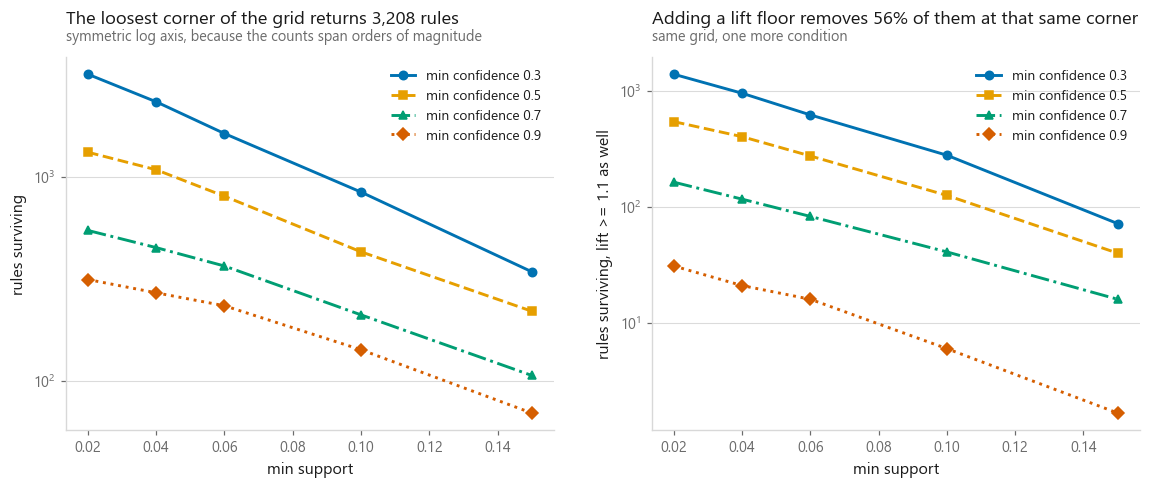

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
dashes = [style.DASHES[i] for i in range(len(confidence_grid))]

for ax, column, ylabel in [(axes[0], "rules", "rules surviving"),
                           (axes[1], LIFT_COLUMN,
                            f"rules surviving, lift >= {LIFT_FLOOR} as well")]:
    for i, c in enumerate(confidence_grid):
        part = grid[grid["min_confidence"] == c]
        ax.plot(part["min_support"], part[column], marker=style.MARKERS[i], ls=dashes[i],
                color=style.PALETTE[i], label=f"min confidence {c:.1f}")
    ax.set_xlabel("min support")
    ax.set_ylabel(ylabel)
    ax.set_yscale("symlog", linthresh=10)
    ax.legend(loc="upper right", fontsize=9)

loosest = grid[(grid["min_support"] == support_grid[0]) &
               (grid["min_confidence"] == confidence_grid[0])].iloc[0]
style.title(axes[0], f"The loosest corner of the grid returns {loosest['rules']:,.0f} rules",
            "symmetric log axis, because the counts span orders of magnitude")
style.title(axes[1],
            f"Adding a lift floor removes "
            f"{1 - loosest[LIFT_COLUMN] / max(loosest['rules'], 1):.0%} "
            f"of them at that same corner",
            "same grid, one more condition")
style.save(fig, FIG / "fig-03-thresholds.png")

The left panel is the trade every tutorial mentions: lower the support floor and
the rule count explodes. The right panel is the one worth having. It is the same
grid with a lift condition added, and the difference between the two panels is
how many of those rules were about nothing.

### How much does the binning decide?

Before drawing any conclusion from these rules, the encoding has to be stress
tested. The temperature, humidity and wind bands were cut at named physical
values. The obvious alternative is equal-frequency bins, which give every band
the same support by construction. If the two encodings disagree wildly about how
many rules exist, then the rules are partly an artefact of the bin edges and
should be reported that way.

In [10]:
items_q = build_items(hours, continuous="quantile")
basket_q = to_basket(items_q)

frequent_q = apriori(basket_q, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
rules_q = association_rules(frequent_q, num_itemsets=len(basket_q),
                            metric="confidence", min_threshold=MIN_CONFIDENCE)
rules_named = all_rules[all_rules["confidence"] >= MIN_CONFIDENCE]

comparison = pd.DataFrame([
    {"binning": "named physical bands", "items": basket.shape[1],
     "frequent itemsets": len(frequent_df), "rules": len(rules_named),
     LIFT_COLUMN: int((rules_named["lift"] >= LIFT_FLOOR).sum()),
     "max lift": rules_named["lift"].max()},
    {"binning": "equal-frequency bins", "items": basket_q.shape[1],
     "frequent itemsets": len(frequent_q), "rules": len(rules_q),
     LIFT_COLUMN: int((rules_q["lift"] >= LIFT_FLOOR).sum()),
     "max lift": rules_q["lift"].max()},
])
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nboth at min_support {MIN_SUPPORT}, min_confidence {MIN_CONFIDENCE}, "
      f"itemsets up to size {MAX_LEN}")

             binning  items  frequent itemsets  rules  rules with lift >= 1.1  max lift
named physical bands     29               1302   1225                     489     5.210
equal-frequency bins     29               1282   1140                     376     3.689

both at min_support 0.03, min_confidence 0.5, itemsets up to size 3


Whatever the table says, say it out loud when you report rules from binned data.
If the counts moved a lot, the honest headline is that support values are a
property of your bin edges as much as of your data. If they barely moved, that is
a small piece of evidence that the structure survives the encoding, and it is
still only evidence about these two encodings.

## 5. When it loses: the confidence trap

Now the part that decides whether a rule mining exercise was worth doing.

Confidence is a conditional probability, and a conditional probability is
impressive only relative to the unconditional one. Almost every hour in this file
is a non-holiday, so "if it is windy and cold, it is not a holiday" will be right
almost every time and will have learned nothing. Confidence alone cannot tell
that apart from a real finding. Lift can, because lift is exactly confidence
divided by the base rate.

In [11]:
kept = all_rules[all_rules["confidence"] >= MIN_CONFIDENCE].copy()
best_confidence = kept.sort_values("confidence", ascending=False).iloc[0]
best_lift = kept.sort_values("lift", ascending=False).iloc[0]


def as_sentence(rule):
    return (f"{' + '.join(sorted(rule['antecedents']))} => "
            f"{' + '.join(sorted(rule['consequents']))}")


print("the single highest-confidence rule")
print(f"  {as_sentence(best_confidence)}")
print(f"  confidence {best_confidence['confidence']:.3f}   "
      f"the consequent happens anyway {best_confidence['consequent support']:.3f} "
      f"of the time   lift {best_confidence['lift']:.3f}")
print("\nthe single highest-lift rule")
print(f"  {as_sentence(best_lift)}")
print(f"  confidence {best_lift['confidence']:.3f}   "
      f"the consequent happens anyway {best_lift['consequent support']:.3f} "
      f"of the time   lift {best_lift['lift']:.3f}")

near_one = kept[(kept["lift"] >= 0.95) & (kept["lift"] <= 1.05)]
print(f"\nrules at confidence >= {MIN_CONFIDENCE} : {len(kept):,}")
print(f"of those, rules whose lift sits between 0.95 and 1.05 : {len(near_one):,} "
      f"({len(near_one) / len(kept):.1%})")
print("those are rules that describe independence and nothing else")

the single highest-confidence rule
  day=working + time=evening => holiday=no
  confidence 1.000   the consequent happens anyway 0.971 of the time   lift 1.030

the single highest-lift rule
  season=autumn + time=afternoon => temp=hot
  confidence 0.805   the consequent happens anyway 0.154 of the time   lift 5.210

rules at confidence >= 0.5 : 1,225
of those, rules whose lift sits between 0.95 and 1.05 : 547 (44.7%)
those are rules that describe independence and nothing else


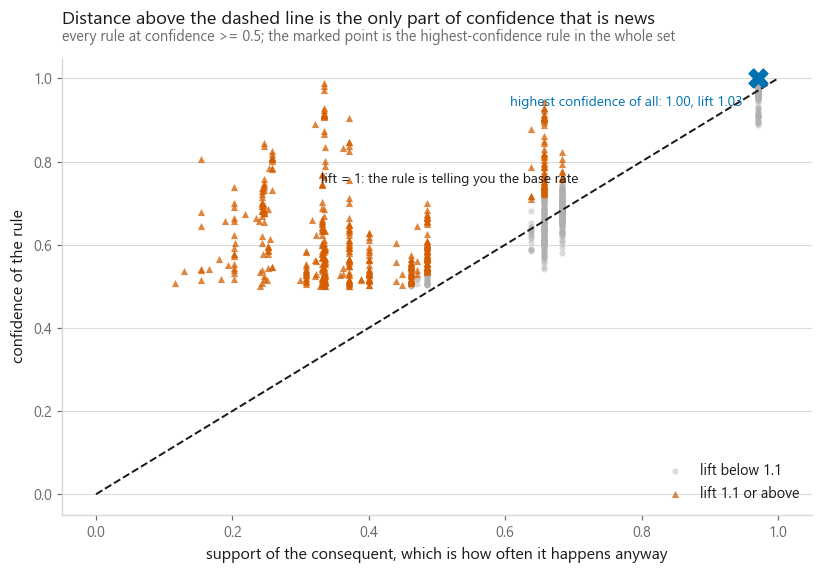

In [12]:
fig, ax = plt.subplots(figsize=(8.8, 5.4))
high_lift = kept["lift"] >= LIFT_FLOOR
ax.scatter(kept.loc[~high_lift, "consequent support"], kept.loc[~high_lift, "confidence"],
           s=16, alpha=0.45, c=style.NEUTRAL, marker="o", linewidths=0,
           label=f"lift below {LIFT_FLOOR}")
ax.scatter(kept.loc[high_lift, "consequent support"], kept.loc[high_lift, "confidence"],
           s=22, alpha=0.75, c=style.HIGHLIGHT, marker="^", linewidths=0,
           label=f"lift {LIFT_FLOOR} or above")
line = np.linspace(0, 1, 50)
ax.plot(line, line, color=style.INK, ls="--", lw=1.3)
ax.annotate("lift = 1: the rule is telling you the base rate", xy=(0.72, 0.72),
            xytext=(-6, 8), textcoords="offset points", ha="right", fontsize=9,
            color=style.INK)
ax.scatter([best_confidence["consequent support"]], [best_confidence["confidence"]],
           s=160, marker="X", c=style.PALETTE[0], zorder=5)
ax.annotate(f"highest confidence of all: {best_confidence['confidence']:.2f}, "
            f"lift {best_confidence['lift']:.2f}",
            xy=(best_confidence["consequent support"], best_confidence["confidence"]),
            xytext=(-10, -18), textcoords="offset points", ha="right", fontsize=9,
            color=style.PALETTE[0])
ax.set_xlabel("support of the consequent, which is how often it happens anyway")
ax.set_ylabel("confidence of the rule")
ax.legend(loc="lower right")
style.title(ax, f"Distance above the dashed line is the only part of confidence that is news",
            f"every rule at confidence >= {MIN_CONFIDENCE}; the marked point is the "
            f"highest-confidence rule in the whole set")
style.save(fig, FIG / "fig-04-lift-vs-confidence.png")

The dashed line is where confidence equals the consequent's base rate, which is
lift exactly 1. Everything sitting on it is a rule that has discovered how common
something is. The marked point is the highest-confidence rule in the set, and its
lift is printed above it.

If you rank rules by confidence, you rank them by how common their consequents
are. That is the trap, and it is why confidence is never a sufficient filter.

### The filter funnel, counted

Four filters, applied in order, with the survivors counted at each step.

In [13]:
def drop_redundant(rules):
    """Remove any rule that a simpler rule already covers at least as well.

    If {a} => {c} has confidence at least as high as {a, b} => {c}, then the
    longer rule adds a condition and buys nothing, so it goes. This is the filter
    that removes most of the apparent volume in a rule set.
    """
    if rules.empty:
        return rules
    keep = []
    key = rules["consequents"].map(lambda s: tuple(sorted(s)))
    for _, group in rules.groupby(key):
        antecedents = list(group["antecedents"])
        confidences = list(group["confidence"])
        for idx, a, conf in zip(group.index, antecedents, confidences):
            covered = any(other < a and other_conf >= conf - 1e-12
                          for other, other_conf in zip(antecedents, confidences))
            if not covered:
                keep.append(idx)
    return rules.loc[sorted(keep)]


STAGE_NAMES = ["generated", f"confidence >= {MIN_CONFIDENCE}",
               f"consequent in under {COMMON_CONSEQUENT:.0%} of hours",
               f"lift >= {LIFT_FLOOR}", "not covered by a simpler rule"]


def funnel(rules, label):
    """Apply the four filters in order. Returns the counts and the survivors."""
    steps = [rules]
    steps.append(steps[-1][steps[-1]["confidence"] >= MIN_CONFIDENCE])
    steps.append(steps[-1][steps[-1]["consequent support"] < COMMON_CONSEQUENT])
    steps.append(steps[-1][steps[-1]["lift"] >= LIFT_FLOOR])
    steps.append(drop_redundant(steps[-1]))

    counts = [len(s) for s in steps]
    print(f"\n{label}")
    for name, count in zip(STAGE_NAMES, counts):
        print(f"  {count:>7,}  ({count / max(counts[0], 1):>6.1%})  {name}")
    return counts, steps[-1]


real_counts, survivors = funnel(all_rules, "the real transactions")
print("\nwhat is left, ranked by lift")
print(readable(survivors, 10, by="lift"))


the real transactions
    6,550  (100.0%)  generated
    1,225  ( 18.7%)  confidence >= 0.5
      459  (  7.0%)  consequent in under 50% of hours
      412  (  6.3%)  lift >= 1.1
      314  (  4.8%)  not covered by a simpler rule

what is left, ranked by lift
                                           rule  support  confidence  consequent support  lift
   season=autumn + time=afternoon  =>  temp=hot    0.052       0.805               0.154 5.210
      temp=hot  =>  demand=high + season=autumn    0.079       0.509               0.116 4.392
      demand=high + season=autumn  =>  temp=hot    0.079       0.679               0.154 4.392
temp=hot  =>  humidity=moderate + season=autumn    0.083       0.538               0.129 4.169
humidity=moderate + season=autumn  =>  temp=hot    0.083       0.644               0.154 4.169
      demand=low + season=spring  =>  temp=cold    0.086       0.739               0.202 3.655
      season=autumn + wind=breezy  =>  temp=hot    0.068       0.541      

### The same funnel on data with every association destroyed

A filter that keeps rules on real data is only impressive if it rejects rules on
data that cannot contain any. So: shuffle each variable independently. Every item
keeps its exact support, every transaction keeps its exact length, and every
relationship between variables is gone.

Any rule that survives this is an artefact of the thresholds, not a finding.

In [14]:
shuffle_rng = np.random.default_rng(SEED)
shuffled_items = pd.DataFrame({c: shuffle_rng.permutation(items[c].to_numpy())
                               for c in items.columns})
shuffled_basket = to_basket(shuffled_items)

same_support = np.allclose(sorted(shuffled_basket.to_numpy().mean(axis=0)),
                           sorted(onehot.mean(axis=0)))
print(f"item supports identical after shuffling: {same_support}")

frequent_null = apriori(shuffled_basket, min_support=MIN_SUPPORT, use_colnames=True,
                        max_len=MAX_LEN)
rules_null = association_rules(frequent_null, num_itemsets=len(shuffled_basket),
                               metric="confidence", min_threshold=0.0)
null_counts, survivors_null = funnel(rules_null, "the shuffled transactions")

print(f"\nhighest lift anywhere in the shuffled data : {rules_null['lift'].max():.3f}")
print(f"highest lift anywhere in the real data     : {all_rules['lift'].max():.3f}")

item supports identical after shuffling: True

the shuffled transactions
    6,408  (100.0%)  generated
      846  ( 13.2%)  confidence >= 0.5
       22  (  0.3%)  consequent in under 50% of hours
        0  (  0.0%)  lift >= 1.1
        0  (  0.0%)  not covered by a simpler rule

highest lift anywhere in the shuffled data : 1.087
highest lift anywhere in the real data     : 5.210


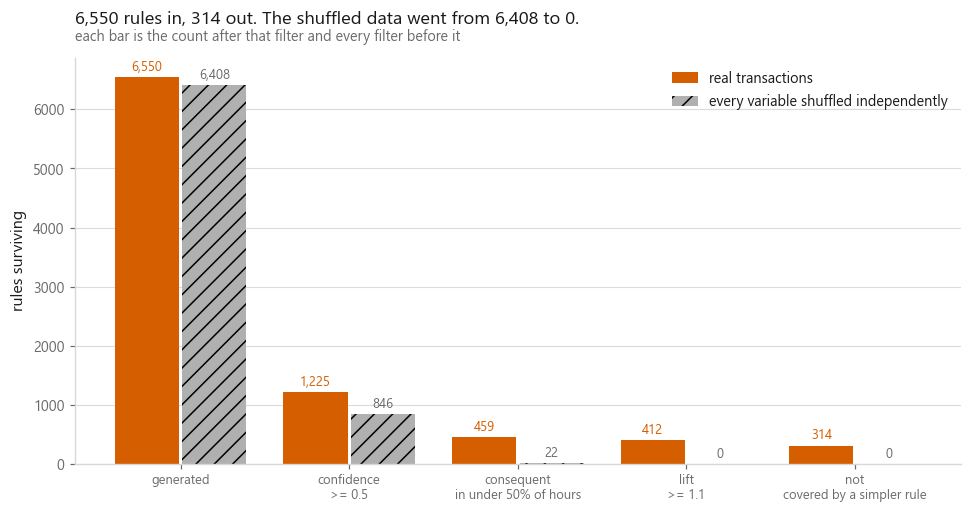

In [15]:
positions = np.arange(len(STAGE_NAMES))
fig, ax = plt.subplots(figsize=(10.4, 4.8))
ax.bar(positions - 0.2, real_counts, width=0.38, color=style.HIGHLIGHT,
       label="real transactions")
ax.bar(positions + 0.2, null_counts, width=0.38, color=style.NEUTRAL, hatch="//",
       label="every variable shuffled independently")
for x, (a, b) in enumerate(zip(real_counts, null_counts)):
    ax.annotate(f"{a:,}", xy=(x - 0.2, a), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8.5, color=style.HIGHLIGHT)
    ax.annotate(f"{b:,}", xy=(x + 0.2, b), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8.5, color=style.MUTED)
ax.set_xticks(positions, [s.replace(" ", "\n", 1) for s in STAGE_NAMES], fontsize=8.5)
ax.set_ylabel("rules surviving")
ax.legend(loc="upper right")
style.title(ax,
            f"{real_counts[0]:,} rules in, {real_counts[-1]:,} out. "
            f"The shuffled data went from {null_counts[0]:,} to {null_counts[-1]:,}.",
            "each bar is the count after that filter and every filter before it")
style.save(fig, FIG / "fig-05-funnel.png")

Compare the two bars at each stage. The confidence filter is the one to watch: if
the shuffled data keeps a large share of its rules through it, then confidence on
its own was never separating signal from arithmetic. Which stage finally collapses
the shuffled column tells you which filter is doing the real work.

The shuffled data still has thousands of hours behind every count, so its lift
values sit close to 1 with only sampling noise around them. On a smaller
transaction file that noise would be wider, and a lift floor of 1.1 would let
nonsense through. The floor you need depends on how many transactions you have,
which is not something the algorithm will remind you about.

### What association rules are and are not

They are a **description of co-occurrence in the data you have**. They are not
predictions, not causal, and not evaluated on held-out data anywhere in this
notebook, because the method has no fitted parameters to overfit and no test set
to hold out. What it can overfit is your attention: search enough rules and some
will look interesting.

The direction in `X => Y` is also weaker than the arrow suggests. Lift is
symmetric, so `X => Y` and `Y => X` always have the same lift and generally
different confidences. If you want direction you need a model with a target, and
most of the rest of this book is that.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You have transactions, want a readable description of what co-occurs, and have someone who can act on a sentence |
| **Avoid it when** | You want prediction. A rule has no held-out score. Use a classifier |
| **Support** | Sets how much you search and how much comes back. Lower it and the count explodes |
| **Confidence** | A conditional probability. Ranking by it ranks by how common the consequents are |
| **Lift** | Confidence divided by the base rate. Symmetric, so it says association and not direction |
| **Downward closure** | The reason Apriori terminates. Every subset of a frequent itemset is frequent, so any candidate with an infrequent subset is skipped unread |
| **Binning** | If your items came from binning continuous columns, the support values belong to your bin edges as much as to your data. Report the encoding |
| **Watch out** | Always filter on lift as well as confidence, and always check what your filters do to shuffled data |
| **Next** | [Principal Component Analysis](../../06-dimensionality-reduction/01-principal-component-analysis/), which starts part 6 |

## What to remember

1. Downward closure is the whole algorithm. Every subset of a frequent itemset is
   frequent, so a candidate with an infrequent subset never gets counted.
2. The subset check costs almost nothing and removes candidates the join cannot
   see, including every itemset that is impossible by construction.
3. Confidence is a conditional probability and means nothing without the base
   rate beside it. The scatter plot in section 5 is the shape of that argument.
4. Lift is symmetric. The arrow in a rule is a formatting choice, not a finding.
5. Most rules are removed by asking whether a simpler rule already covered them.
   Count the survivors at every stage and print the counts.
6. Shuffle every column independently and run the same pipeline. Whatever
   survives that is your false positive rate, and you should know it before you
   show anyone a rule.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [06-01 Principal Component Analysis](../../06-dimensionality-reduction/01-principal-component-analysis/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#AssociationRules` `#Apriori` `#MarketBasketAnalysis`
`#UnsupervisedLearning` `#Python` `#mlxtend` `#DataScience` `#MLTutorial` `#Lift`